In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline jest potrzebne zeby wyswietlac wykresy w notebooku

%matplotlib inline

# PODEJSCIE FUNKCYJNE

In [2]:
x = np.arange(11)
y = x ** 2

W podejściu funkcyjnym wszystko odbywa się bardzo bezpośrednio. Wystarczy, że użyjemy metody plot, a jako argumentów stworzonych wcześniej x oraz y.

In [8]:
#wyswietlamy

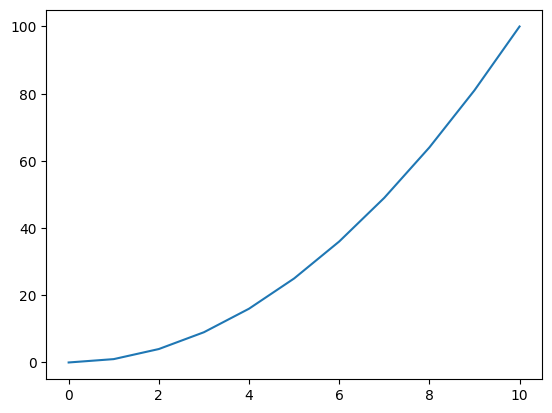

In [3]:
plt.plot(x,y)

edycja


In [6]:
plt.show()  #jak to wyzej 

Text(0.5, 1.0, 'Tytuł wykresu')

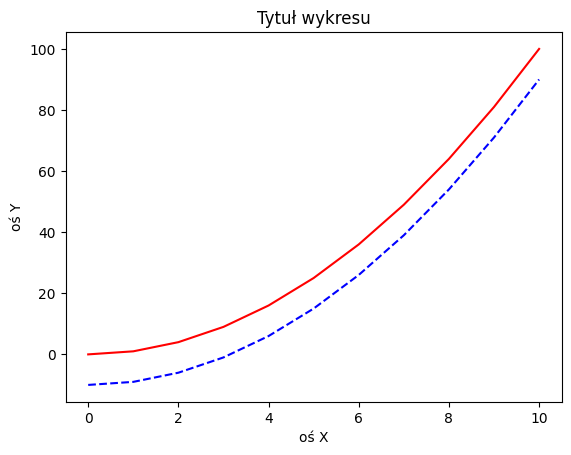

In [7]:
plt.plot(x,y, color='red') # zmieniamy kolor poprzedniej linii
plt.plot(x,y-10,color='blue',ls='dashed') # dodajemy drugą linię na tym samym wykresie
plt.xlabel('oś X') # dodajemy opis osi X
plt.ylabel('oś Y') # dodajemy opis osi Y
plt.title('Tytuł wykresu') # dodajemy tytuł wykresu

edycja cd

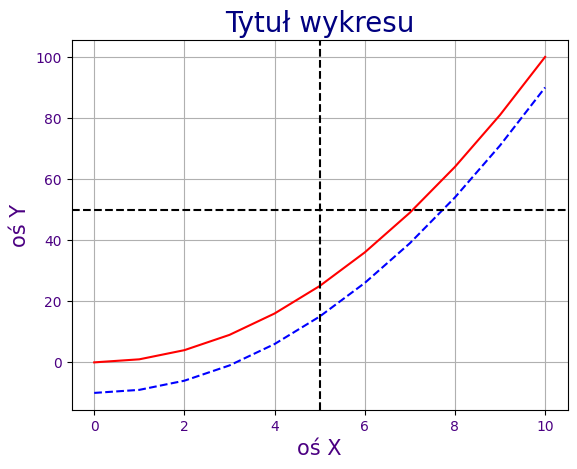

In [9]:
plt.plot(x,y, color='red') # zmieniamy kolor poprzedniej linii
plt.plot(x,y-10,color='blue',ls='dashed') # dodajemy drugą linię na tym samym wykresie
plt.xlabel('oś X', size=15, color='indigo') # dodajemy opis osi X
plt.ylabel('oś Y', size=15, color='indigo') # dodajemy opis osi Y
plt.title('Tytuł wykresu', size=20, color='navy') # dodajemy tytuł wykresu
plt.xticks(color='indigo') #kolor liczb na osi
plt.yticks(color='indigo')
plt.grid()
plt.axhline(y=50, color='k', linestyle='--')
plt.axvline(x=5, color='k', linestyle='--')
plt.show()

# subplot

Dzięki niej możemy stworzyć siatkę niezależnych od siebie zestawów osi na jednym obszarze. Wykorzystamy trzy argumenty tej funkcji, które oznaczać będą odpowiednio: liczbę wierszy, liczbę kolumn, pozycję wykresu, na którym będziemy wykonywać kolejne operacje.

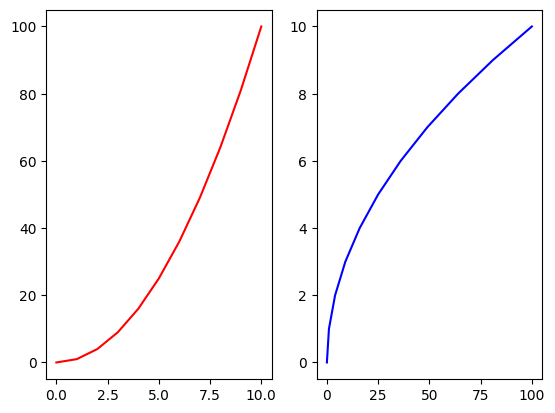

In [10]:
plt.subplot(1,2,1)
plt.plot(x,y,color='red')

plt.subplot(1,2,2)
plt.plot(y,x,color='blue')

# KOCH_snowflake

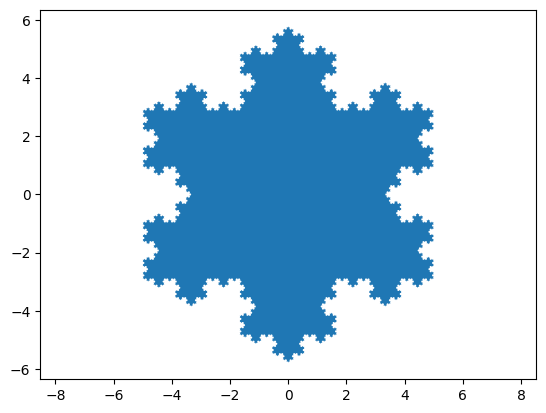

In [12]:
def koch_snowflake(order, scale=10):

    """
    Return two lists x, y of point coordinates of the Koch snowflake.
    Parameters
    ----------
    order : int
        The recursion depth.
    scale : float
        The extent of the snowflake (edge length of the base triangle).
    """

    def _koch_snowflake_complex(order):
        if order == 0:

            # initial triangle
            angles = np.array([0, 120, 240]) + 90
            return scale / np.sqrt(3) * np.exp(np.deg2rad(angles) * 1j)

        else:

            ZR = 0.5 - 0.5j * np.sqrt(3) / 3
            p1 = _koch_snowflake_complex(order - 1)  # start points
            p2 = np.roll(p1, shift=-1)  # end points
            dp = p2 - p1  # connection vectors
            new_points = np.empty(len(p1) * 4, dtype=np.complex128)
            new_points[::4] = p1
            new_points[1::4] = p1 + dp / 3
            new_points[2::4] = p1 + dp * ZR
            new_points[3::4] = p1 + dp / 3 * 2

            return new_points

    points = _koch_snowflake_complex(order)
    x, y = points.real, points.imag
    return x, y

x, y = koch_snowflake(order=5)
plt.fill(x, y)
plt.axis('equal')
plt.show()

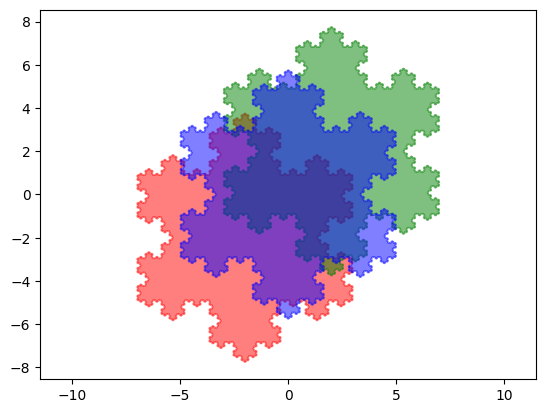

In [13]:
plt.fill(x-2, y-2, color='red', alpha=0.5)
plt.fill(x+2, y+2, color='green', alpha=0.5)
plt.fill(x, y, color='blue', alpha=0.5)
plt.axis('equal')
plt.show()

# wykres puntkowy


Chcąc zaprezentować możliwości wykresu punktowego, stwórzmy macierz o kształcie (1000,2) wypełnioną losowymi wartościami


In [14]:
rand_arr = np.random.randint(1,1000,2000).reshape(1000,2)

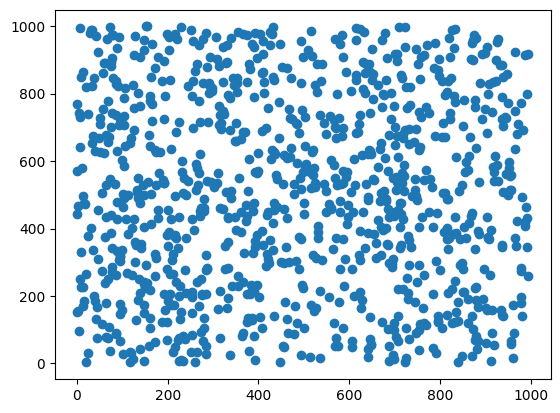

In [15]:
plt.scatter(rand_arr[:,0],rand_arr[:,1])

W kolejnym kroku spróbujemy zmodyfikować ten wykres. Po pierwsze, będziemy chcieli wyróżnić kolorem czerwonym punkty, które zarówno na osi X oraz osi Y mają wartość większą od liczby 500. Po drugie, zmienimy rozmiar wykresu w taki sposób, aby był jednocześnie większy niż poprzedni i dwa razy dłuższy na osi X w porównaniu do osi Y.

Wyróżnienie poszczególnych punktów polega na wprowadzeniu do funkcji scatter sekwencji, której kolejne elementy określają kolor odpowiadającego im punktu na wykresie.

Ponieważ chcemy wyróżnić punkty, które mają wartość większą od 500 na obu osiach – efektem będzie wykres, którego prawa górna ćwiartka będzie w całości w kolorze czerwonym.

Stwórzmy zatem sekwencję kolorów, wykorzystując umiejętności zdobyte w rozdziale poświęconym NumPy!

In [16]:
cmap = np.empty(rand_arr.shape,dtype='object')
cmap[:] = 'blue'
cmap[rand_arr.min(axis=1)>500] = 'red'

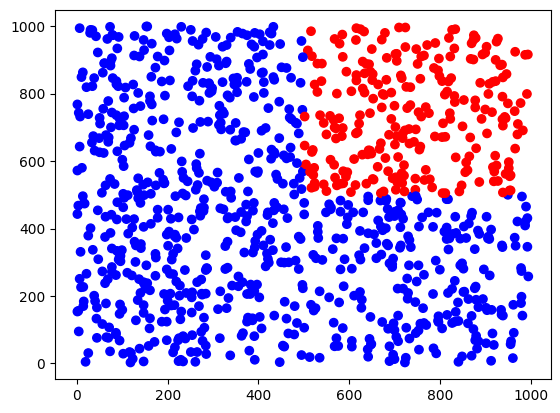

In [17]:
plt.scatter(rand_arr[:,0],rand_arr[:,1],c=cmap[:,0])

Zanim jednak stworzymy wykres, chcemy odpowiednio zwiększyć jego rozmiar. Możemy to zrobić, wywołując funkcję figure przed scatter.

plt.figure(figsize=(10,5))

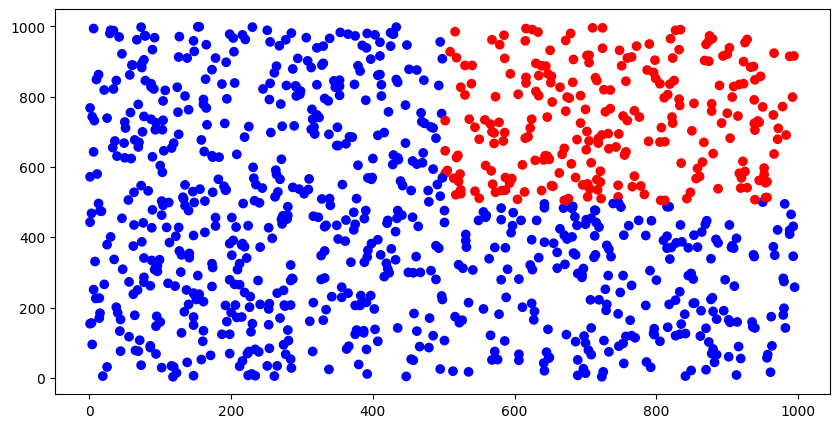

In [18]:
plt.figure(figsize=(10,5))
plt.scatter(rand_arr[:,0],rand_arr[:,1],c=cmap[:,0])

# wykres kolowy

Wykres kołowy stworzymy, bazując na wartościach przypisanych do zmiennej pie_data i etykietach dostępnych pod zmienną labels.


In [19]:
pie_data = np.array([30,20,20,40,10])
labels = ['A','B','C','D','E']

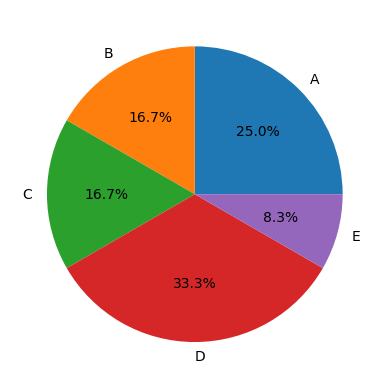

In [20]:
plt.pie(pie_data,labels=labels,autopct='%1.1f%%')
plt.show()

# PODEJSCIE OBIEKTOWE

Wróćmy do pierwszego wykresu, który tworzyliśmy na początku tej części modułu. Tym razem stworzymy go zgodnie z podejściem obiektowym. Podejście to polega w pierwszej kolejności na tworzeniu obiektów będących poszczególnymi elementami wykresu, a następnie przypisywanie im określonych właściwości, zamiast wykonywania po kolei funkcji dodających kolejne właściwości do wykresu.

W związku z tym każdy wykres będziemy rozpoczynać od zdefiniowania obiektu, który możemy zobrazować sobie jako pusty wykres bez żadnych właściwości. Białe płótno, na które dodajemy kolejne elementy.

In [22]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

Obiektem, który będziemy chcieli dodać na płótno, jest para osi. Zrobimy to poprzez wykonanie funkcji add_axes na obiekcie figure.

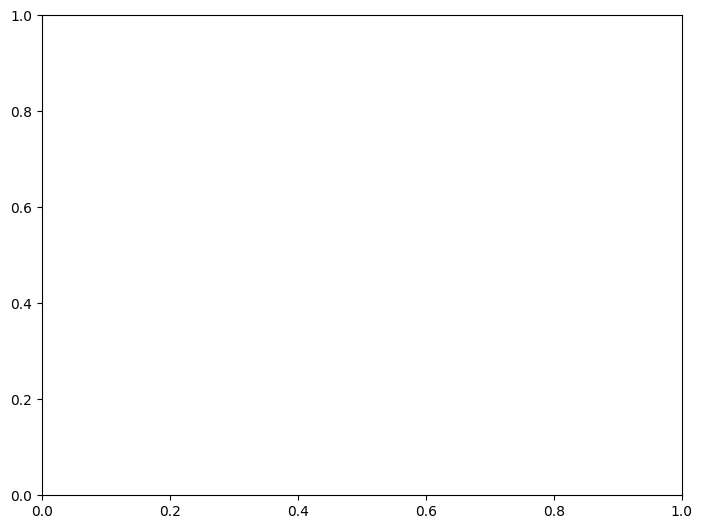

In [23]:
fig = plt.figure()
axes = fig.add_axes([0,0,1,1]) # left, bottom, width, height

Wartości w liście wprowadzonej do funkcji add_axes oznaczają odpowiednio:

W którym miejscu od lewej rozpoczynamy kreślenie osi.
W którym miejscu od spodu rozpoczynamy kreślenie osi.
Jak szeroka ma być oś X.
Jak wysoka ma być oś Y.
Wszystkie te wartości muszą mieścić się w przedziale między 0 a 1, ponieważ stanowią ułamek wymiarów płótna, na którym tworzymy wykres.

Obiekt odzwierciedlający osie wykresu jest przypisany do zmiennej axes. Na tym obiekcie możemy wykonywać funkcje parametryzujące jego rodzaj i wygląd.

Text(0.5, 1.0, 'Tytuł wykresu')

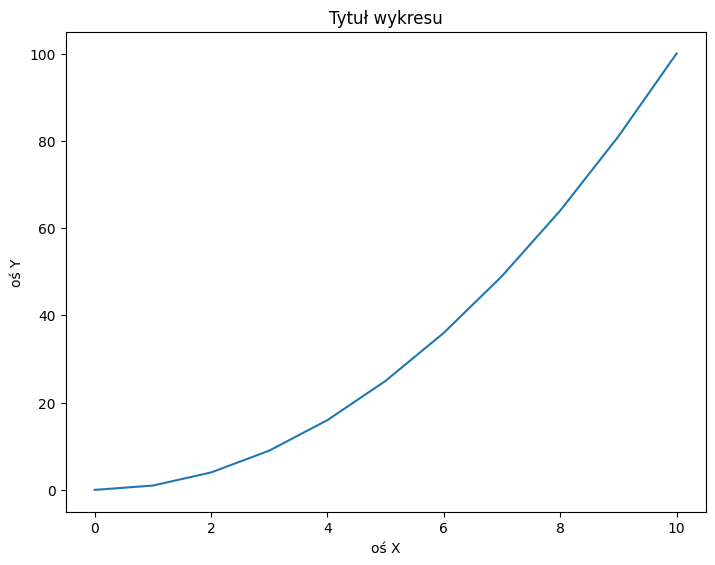

In [24]:
fig = plt.figure()
axes = fig.add_axes([0,0,1,1]) # left, bottom, width, height
x = np.arange(11)
y = x ** 2
axes.plot(x,y)
axes.set_xlabel('oś X')
axes.set_ylabel('oś Y')
axes.set_title('Tytuł wykresu')

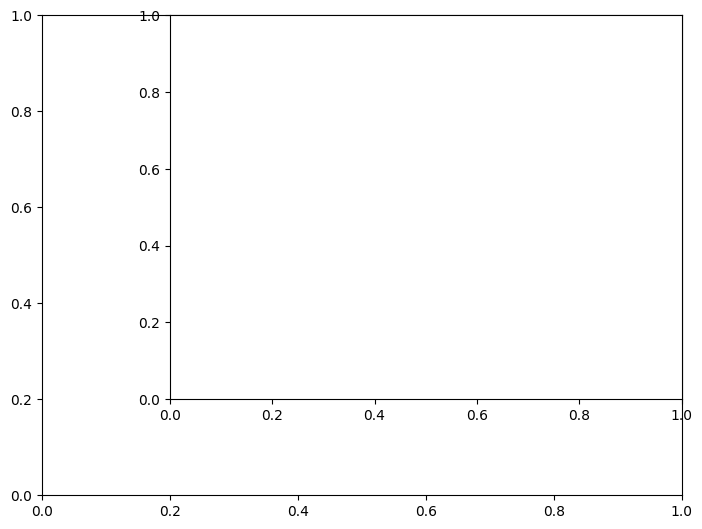

In [25]:
fig = plt.figure()
axes1 = fig.add_axes([0,0,1,1])
axes2 = fig.add_axes([.2,.2,.8,.8])

In [26]:
axes1.plot(x,y)
axes2.scatter(rand_arr[:,0],rand_arr[:,1])

In [28]:
axes1.set_xlabel('Exponential')
axes2.set_xlabel('Random')

Text(0.5, 100.44444444444444, 'Random')

Text(0.5, 0, 'Random')

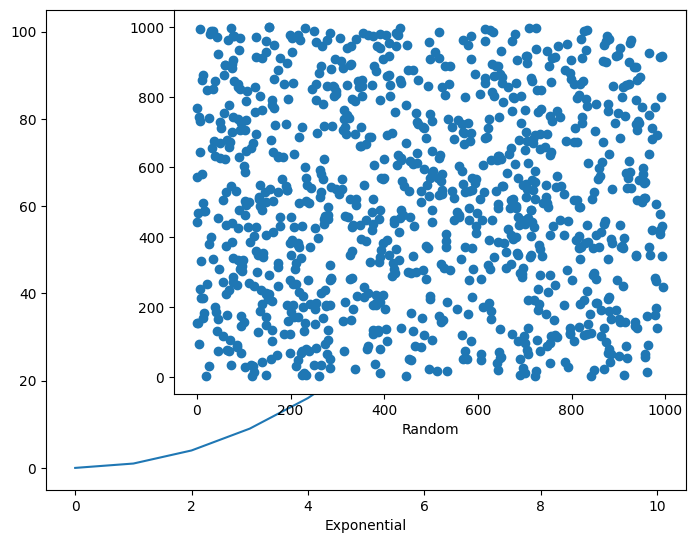

In [30]:
fig = plt.figure()
axes1 = fig.add_axes([0,0,1,1])
axes2 = fig.add_axes([.2,.2,.8,.8])
axes1.plot(x,y)
axes2.scatter(rand_arr[:,0],rand_arr[:,1])
axes1.set_xlabel('Exponential')
axes2.set_xlabel('Random')

Wcześniej pokazywaliśmy, jak tworzyć niezależne zestawy osi w układzie przypominającym siatkę lub macierz przy podejściu funkcyjnym.

Podejście obiektowe do tego problemu ma wiele zalet w stosunku do rozwiązania w podejściu funkcyjnym, co postaramy się udowodnić na kolejnym przykładzie.

Wykorzystamy funkcję subplots, aby za jednym razem stworzyć obiekt Figure oraz obiekty dla tylu zestawów osi, ile potrzebujemy.

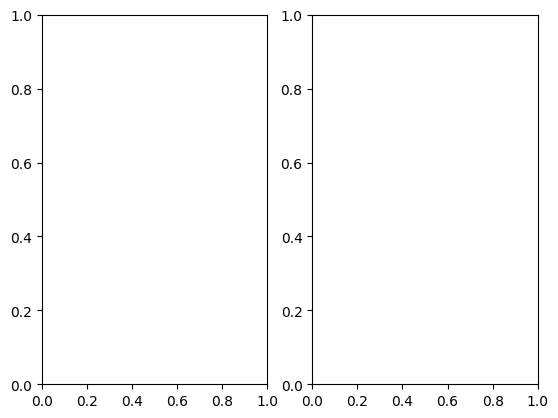

In [31]:
fig,axes = plt.subplots(nrows=1,ncols=2)

Zmienna axes w tym układzie jest tablicą zawierającą kolejne zestawy osi. Możemy zatem edytować wygląd i zawartość wykresu dla każdego z zestawów, wywołując ich pozycję na liście axes.



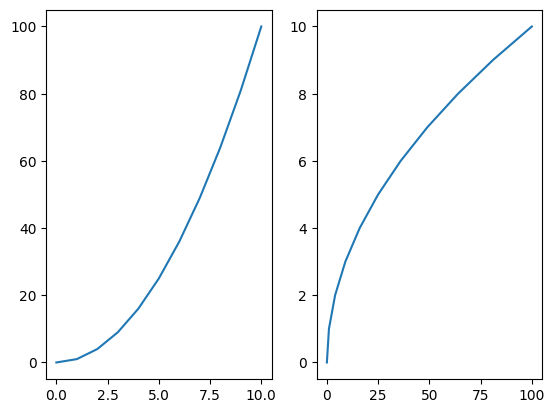

In [32]:
fig,axes = plt.subplots(nrows=1,ncols=2)

axes[0].plot(x,y)
axes[1].plot(y,x)